In [1]:
from astropy.io import fits
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.wcs import WCS
from mpl_toolkits import mplot3d
import scienceplots
import copy
import sys
import os
from besta import sfh as besta_sfh
from scipy.interpolate import splev
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from besta.kinematics import convolve_variable_gaussian_kernel

plt.style.use('science')

#-- Open Data --
red = fits.open('data/L1/stack_3095663.fit')
blue = fits.open('data/L1/stack_3095664.fit')
fibtable = red[6].data
fibtable_blue = blue[6].data

# Read the redshift catalog
z_cat = pd.read_csv('sheets/A2142_final_redshift_catalog.csv')

nspec_folder = 'nspec'

In [2]:
print(fibtable.columns.names)

['Nspec', 'FIBREID', 'CNAME', 'FIBRERA', 'FIBREDEC', 'XPOSITION', 'YPOSITION', 'STATUS', 'TARGID', 'TARGX', 'TARGY', 'TARGSRVY', 'ORIENTAT', 'RETRIES', 'TARGNAME', 'TARGRA', 'TARGDEC', 'TARGEPOCH', 'TARGCAT', 'TARGPMRA', 'TARGPMDEC', 'TARGPARAL', 'TARGUSE', 'TARGPROG', 'TARGCLASS', 'TARGPRIO', 'MAG_G', 'EMAG_G', 'MAG_R', 'EMAG_R', 'MAG_I', 'EMAG_I', 'MAG_GG', 'EMAG_GG', 'MAG_BP', 'EMAG_BP', 'MAG_RP', 'EMAG_RP', 'RMS_arc1', 'RMS_arc2', 'Resol', 'Helio_cor', 'Sky_shift', 'Sky_scale', 'SNR', 'Meanflux', 'Npix_sat1', 'Npix_sat2']


# Redshifts

In [3]:
# Choose only science targets
sci_targs = fibtable['TARGUSE'] == 'T'

# Apply to fibtable columns
nspec    = fibtable['NSPEC'][sci_targs].astype(int)
targid   = fibtable['TARGID'][sci_targs].astype(str)
targname = fibtable['TARGNAME'][sci_targs].astype(str)
targra   = fibtable['TARGRA'][sci_targs].astype(float)
targdec  = fibtable['TARGDEC'][sci_targs].astype(float)
mag_r    = fibtable['MAG_R'][sci_targs].astype(float)
mag_g    = fibtable['MAG_G'][sci_targs].astype(float)
snr_red  = fibtable['SNR'][sci_targs].astype(float)
snr_blue = fibtable_blue['SNR'][sci_targs].astype(float)

# Build SkyCoord objects
weave_coords = SkyCoord(ra=targra*u.deg, dec=targdec*u.deg)
z_coords = SkyCoord(ra=z_cat['RA'].values*u.deg, dec=z_cat['DEC'].values*u.deg)

# Match each WEAVE target to nearest redshift catalog
idx, sep, _ = weave_coords.match_to_catalog_sky(z_coords)
match_mask = sep < 2*u.arcsec  # Keep only matches within 2 arcseconds
print(f"Matched: {match_mask.sum()} / {len(weave_coords)}")

# Build output dataframe
df = pd.DataFrame({
    'NSPEC'      : nspec[match_mask],
    'TARGID'     : targid[match_mask],
    'MAG_R'      : mag_r[match_mask],
    'MAG_G'      : mag_g[match_mask],
    'SNR_RED'    : snr_red[match_mask],
    'SNR_BLUE'   : snr_blue[match_mask],
    'WEAVE_RA'   : targra[match_mask],
    'WEAVE_DEC'  : targdec[match_mask],
    'CSV_RA'     : z_cat['RA'].values[idx[match_mask]],
    'CSV_DEC'    : z_cat['DEC'].values[idx[match_mask]],
    'FLAG_Z'     : z_cat['FLAG_Z'].values[idx[match_mask]],
    'Z_FINAL'    : z_cat['Z_FINAL'].values[idx[match_mask]],
})

# Save the redshifts, targids and coordinates to a new file
df.to_csv('sheets/crossmatched.csv', index=False)
df = df[df['FLAG_Z'] > 1]
df.to_csv('sheets/filtered_flagz.csv', index=False)
df = pd.read_csv('sheets/filtered_flagz.csv')
print(f'Length of Redshift Catalog: {len(z_cat)}, Length of WEAVE Targets: {len(df)}')

Matched: 736 / 763
Length of Redshift Catalog: 840, Length of WEAVE Targets: 612


In [4]:
# Einasto cut: FLAG_Z > 1 and 0.084 < Z_FINAL < 0.100
A2142_einasto = df[(df['Z_FINAL'] > 0.084) & (df['Z_FINAL'] < 0.100)]
A2142_einasto.to_csv('sheets/A2142_einasto.csv', index=False)
print(len(A2142_einasto))

184


In [5]:
#-----------------------------------
#----- GAUSSIAN REDSHIFT FIT -------
#-----------------------------------

# Use a generous window to not pre-bias the fit
z_window = df[(df['Z_FINAL'] > 0.07) & (df['Z_FINAL'] < 0.115)]['Z_FINAL'].values
bins = 100

# --- Histogram the data ---
counts, bin_edges = np.histogram(z_window, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# --- Define Gaussian ---
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Initial guesses: amplitude ~ peak count, mu ~ 0.088, sigma ~ 0.003
p0 = [counts.max(), 0.088, 0.003]
popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties on parameters
amp, mu, sigma = popt

# --- Apply a sigma-based membership cut ---
z_lo = mu - 3*sigma
z_hi = mu + 3*sigma

A2142_gauss = df[(df['Z_FINAL'] > z_lo) & (df['Z_FINAL'] < z_hi)]
A2142_gauss.to_csv('sheets/A2142_gaussian.csv', index=False)

old_nspec = set(A2142_einasto['NSPEC'])
new_nspec = set(A2142_gauss['NSPEC'])

gained = sorted(new_nspec - old_nspec)
lost   = sorted(old_nspec - new_nspec)

print(f"Gaussian fit:  μ = {mu:.5f} ± {perr[1]:.5f}")
print(f"               σ = {sigma:.5f} ± {perr[2]:.5f}")
print(f"  3σ window: [{mu - 3*sigma:.4f}, {mu + 3*sigma:.4f}]")
print(f"Gaussian (3σ) cut: {len(A2142_gauss)} members  |  old hard cut: {len(A2142_einasto)}")
print(f"New redshift bounds: {z_lo} < z < {z_hi}")
print(f"Nspecs Gained ({len(gained)}): {gained}")
print(f"Nspecs Lost ({len(lost)}): {lost}")

Gaussian fit:  μ = 0.08877 ± 0.00012
               σ = 0.00200 ± 0.00012
  3σ window: [0.0828, 0.0948]
Gaussian (3σ) cut: 175 members  |  old hard cut: 184
New redshift bounds: 0.08276230886361129 < z < 0.09477403194412502
Nspecs Gained (2): [449, 902]
Nspecs Lost (11): [54, 91, 101, 211, 271, 300, 333, 747, 750, 777, 782]


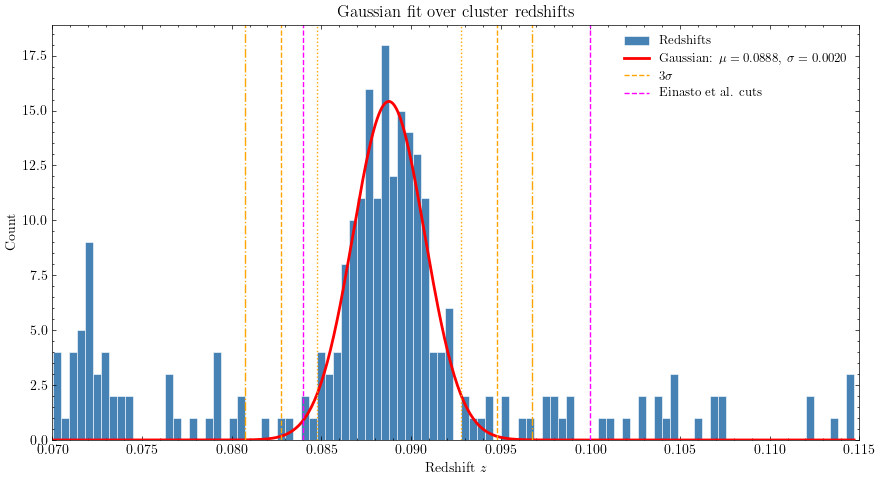

In [6]:
# --- Plot ---
z_fit = np.linspace(z_window.min(), z_window.max(), 500)
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(z_window, bins=bins, color='steelblue', edgecolor='white',
        linewidth=0.4, label='Redshifts')
ax.plot(z_fit, gaussian(z_fit, *popt), 'r-', lw=2,
        label=rf'Gaussian: $\mu={mu:.4f}$, $\sigma={sigma:.4f}$')
for n, ls in [(2, ':'), (3, '--'), (4, '-.')]:
    ax.axvline(mu - n*sigma, color='orange', ls=ls, lw=1.0, label=rf'${n}\sigma$' if n == 3 else '_')
    ax.axvline(mu + n*sigma, color='orange', ls=ls, lw=1.0)
ax.axvline(0.084, color='magenta', ls='--', lw=1.0, label='Einasto et al. cuts')
ax.axvline(0.100, color='magenta', ls='--', lw=1.0)
ax.axvline()
ax.set_xlabel('Redshift $z$')
ax.set_ylabel('Count')
ax.set_title('Gaussian fit over cluster redshifts')
ax.legend(fontsize=9)
ax.set_xlim(0.07, 0.115)
plt.tight_layout()
plt.savefig('plots/redshift/A2142_gaussian_fit.pdf', bbox_inches='tight')
plt.show()

# Flux, Errors & Mask

In [14]:
def extract_spec(hdu_red, hdu_blue, nspec, forcesnr=False):
    fibtable = hdu_red[6].data
    nspecs = fibtable['Nspec'].tolist()
    i = nspecs.index(nspec)
    
    def _extract_arm(hdu, snr):
        spec      = hdu[1].data[i]
        ivar      = hdu[2].data[i]
        sens_func = hdu[5].data[i]
        
        flux = spec * sens_func

        if forcesnr:
            # Error on calibrated flux: sigma_cal = S / sqrt(ivar_raw)
            error = np.full_like(ivar, np.nan)
            valid = ivar > 0
            error[valid] = np.where(flux[valid] != 0, np.abs(flux[valid]) / snr, 1e5)

        else:
            # Error on calibrated flux: sigma_cal = S / sqrt(ivar_raw)
            error = np.full_like(ivar, np.nan)
            valid = ivar > 0
            error[valid] = sens_func[valid] / np.sqrt(ivar[valid])
            

        wcs        = WCS(hdu[1].header)
        pix_coords = np.arange(flux.size)
        wl         = wcs.spectral.array_index_to_world(pix_coords).to(u.AA).value

        flux  = np.nan_to_num(flux,  nan=0.0, posinf=0.0, neginf=0.0)
        error = np.nan_to_num(error, nan=1e5, posinf=1e5, neginf=1e5)
        ivar  = np.nan_to_num(ivar,  nan=0.0, posinf=0.0, neginf=0.0)

        return {"wl": wl, "flux": flux, "error": error, "ivar": ivar}

    return {
        "red":     _extract_arm(hdu_red, 15),
        "blue":    _extract_arm(hdu_blue, 5),
        "fibreid": fibtable["FIBREID"][i],
        "targid":  fibtable["TARGID"][i],
        "nspec":   fibtable["Nspec"][i],
    }

def build_masks(spec, wlrange_blue, wlrange_red, region_masks=None, pad=15):
    """
    Build boolean masks for blue and red arm spectra.
    Parameters
    ----------
    spec : dict
        Nested dict with keys 'blue' and 'red', each containing
        'wl', 'flux', 'error', 'ivar' arrays.
    wlrange_blue : array-like
        Wavelength array or [min, max] for the blue arm.
    wlrange_red : array-like
        Wavelength array or [min, max] for the red arm.
    region_masks : dict, optional
        Dict with keys 'blue' and/or 'red', each a list of (lo, hi)
        tuples for wavelength regions to exclude.
        If not provided, no region masking is applied.
    pad : float, optional
        Padding in Angstroms around zero-flux pixels to mask. Default 15.
    Returns
    -------
    mask_blue, mask_red : np.ndarray
        Boolean arrays (True = good pixel).
    """
    if region_masks is None:
        region_masks = {}

    wlranges = {"blue": wlrange_blue, "red": wlrange_red}
    masks = {}

    for arm in ["blue", "red"]:
        wl   = spec[arm]["wl"]
        flux = spec[arm]["flux"]
        ivar = spec[arm]["ivar"]
        wr   = wlranges[arm]

        # --- Wavelength range mask ---
        wlrange_mask = (wl >= wr[0]) & (wl <= wr[-1])

        # --- Finite flux mask ---
        finite_mask = np.isfinite(flux)

        # --- Inverse variance mask ---
        ivar_mask = ivar > 1e-10

        # --- Zero-flux padding mask ---
        zeroflux_mask = np.zeros(len(wl), dtype=bool)
        for idx in np.where(flux == 0)[0]:
            lo = np.searchsorted(wl, wl[idx] - pad)
            hi = np.searchsorted(wl, wl[idx] + pad, side='right')
            zeroflux_mask[lo:hi] = True

        # --- User-defined region mask ---
        arm_regions = region_masks.get(arm, [])
        if arm_regions:
            region_mask = np.any(
                [(wl >= a) & (wl <= b) for a, b in arm_regions],
                axis=0
            )
        else:
            region_mask = np.zeros(len(wl), dtype=bool)

        # --- Combine all masks ---
        # A pixel is good (True) only if it passes every individual criterion
        masks[arm] = (wlrange_mask & finite_mask & ivar_mask & ~zeroflux_mask & ~region_mask)

    return masks["blue"], masks["red"]

In [15]:
A2142_einasto = pd.read_csv('sheets/A2142_einasto.csv')
extras = [449, 902] # extra nspecs from the gaussian fit
nspecs_A2142 = A2142_einasto['NSPEC'].tolist() + extras

#--Set wavelength range--
wlrange_blue = np.arange(3800, 5900)
wlrange_red  = np.arange(5900, 7500)

for i, nspec in enumerate(nspecs_A2142):

    #--Create folder for given spectra--
    os.makedirs(f'output/{nspec_folder}/{nspec}', exist_ok=True)
    
    # --Extract spectra from filtered HUD's--
    spec = extract_spec(red, blue, nspec, forcesnr=False)
    targid = spec["targid"]
    fibreid = spec["fibreid"]

    #--Save wavelength, flux and error to a .txt file--
    np.savetxt(f'output/{nspec_folder}/{nspec}/redflux_{nspec}.txt',  np.array([spec['red']['wl'], spec['red']['flux'], spec['red']['error']]).T, delimiter='\t', fmt="%s")
    np.savetxt(f'output/{nspec_folder}/{nspec}/blueflux_{nspec}.txt', np.array([spec['blue']['wl'], spec['blue']['flux'], spec['blue']['error']]).T, delimiter='\t', fmt="%s")

    #--Masking--
    mask_blue, mask_red = build_masks(spec, wlrange_blue, wlrange_red)
    np.savetxt(f'output/{nspec_folder}/{nspec}/bluemask_{nspec}.txt', mask_blue)
    np.savetxt(f'output/{nspec_folder}/{nspec}/redmask_{nspec}.txt', mask_red)

In [16]:
def shade_masked(ax, wl, mask, **kwargs):
    """Shade regions where mask is False (i.e. masked out)."""
    in_masked = False
    start = None
    label = kwargs.pop('label', None)
    for j, good in enumerate(mask):
        if not good and not in_masked:
            start = wl[j]
            in_masked = True
        elif good and in_masked:
            ax.axvspan(start, wl[j], **kwargs, label=label)
            label = None   # only label the first span
            in_masked = False
    if in_masked:
        ax.axvspan(start, wl[-1], **kwargs, label=label)

def load_spec_from_files(nspec):
    """Load spectrum data from saved .txt files."""
    base = f'./output/{nspec_folder}/{nspec}'
    
    red_data  = np.loadtxt(f'{base}/redflux_{nspec}.txt',  delimiter='\t')
    blue_data = np.loadtxt(f'{base}/blueflux_{nspec}.txt', delimiter='\t')
    mask_red  = np.loadtxt(f'{base}/redmask_{nspec}.txt').astype(bool)
    mask_blue = np.loadtxt(f'{base}/bluemask_{nspec}.txt').astype(bool)
    
    return {
        'red':  {'wl': red_data[:,0],  'flux': red_data[:,1],  'error': red_data[:,2]},
        'blue': {'wl': blue_data[:,0], 'flux': blue_data[:,1], 'error': blue_data[:,2]},
        'mask_red':  mask_red,
        'mask_blue': mask_blue,
    }

def plot_spec(nspec, ylim=(-0.2e-15, 0.3e-15)):
    """Plot spectrum and masks for a given nspec, loaded from text files."""
    data = load_spec_from_files(nspec)

    arms = [
        ('red',  data['red'],  wlrange_red,  data['mask_red'],  'firebrick', 'Red arm'),
        ('blue', data['blue'], wlrange_blue, data['mask_blue'], 'steelblue', 'Blue arm'),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
    fig.suptitle(f'Spectra for nspec={nspec}', fontsize=14)

    for ax, (arm, s, wlrange, mask, color, label) in zip(axes, arms):
        ax.plot(s['wl'], s['flux'], color=color, lw=0.8, label=label)
        ax.fill_between(s['wl'], s['flux'] - s['error'], s['flux'] + s['error'],
                        color='gray', alpha=0.4, label=r'Error ($\sigma$)')
        ax.axvline(wlrange[0],  color='black', ls='--', lw=0.8, label='Fitting range')
        ax.axvline(wlrange[-1], color='black', ls='--', lw=0.8)
        shade_masked(ax, s['wl'], mask, color='lavender', alpha=0.6, label='Masked')
        ax.set_ylabel(r'Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)')
        ax.set_xlabel('Wavelength (Å)')
        ax.set_ylim(ylim)
        ax.legend(loc='upper right')

    plt.show()

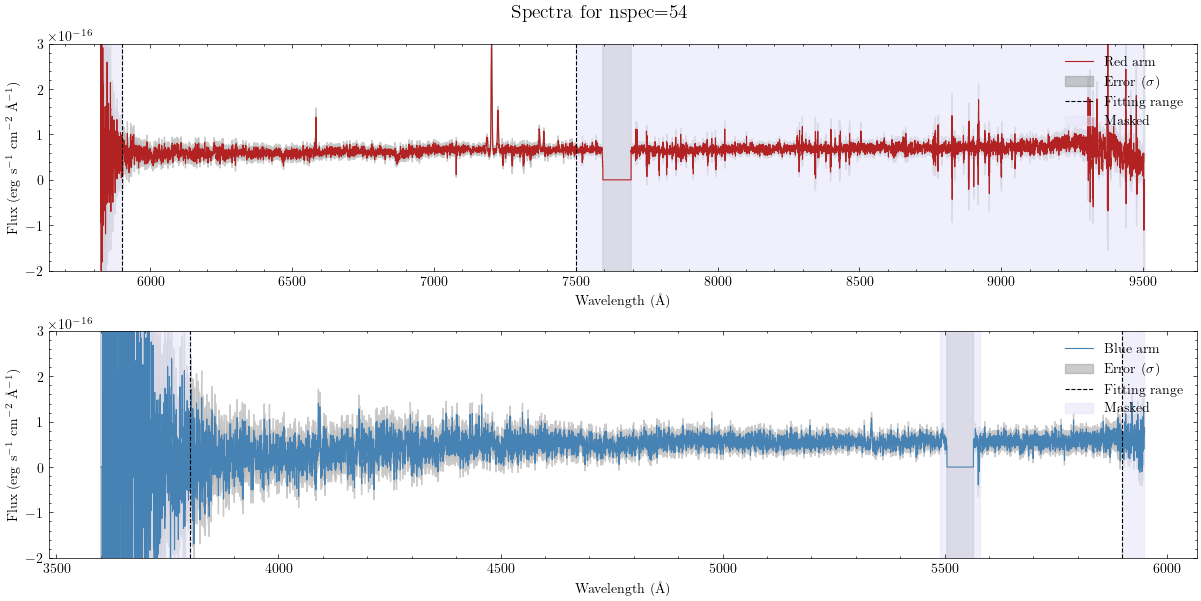

In [17]:
plot_spec(54)

# Priors

In [11]:
sfh = "FixedMassFracSFH"
args = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
sfh_model = getattr(besta_sfh, sfh)(args)
sfh_model.make_ini("fixedmass_sfh_values.ini")

to_add = """[kinematics]
; Kinematics                                                                   
los_vel = -100 0 100 # Line-of-sight velocity, with a prior between -100 and 100 km/s
los_sigma = 50 200 400 # Velocity dispersion, with a prior between 50 and 400 km/s
los_h3 = 0.0 
los_h4 = 0.0
[dust.extinction]
; Dust extinction
a_v = 0 0.1 1.5 # Dust extinction in the V-band, with a prior between 0 and 1.5
[parameters]
; Metallicity
alpha_powerlaw = 0.0 1.0 4.0 # The stellar mass power-law exponent, with a prior between 0 and 4
ism_metallicity_today = 0.005 0.01 0.08 # The fraction of the ISM metallicity at the time of observation, with a prior between 0.005 and 0.08
"""

with open("fixedmass_sfh_values.ini", "a") as f:
    f.write(to_add)

# Line Spread Function (LSF)

In [12]:
#--Open Data--
lsffile_blue = 'data/CAL/lsf_BLUEL11_MOS-A.fits'
lsffile_red  = 'data/CAL/lsf_REDL11_MOS-A.fits'
lsffile_emiles = "e-miles_spectral_resolution.dat"

# Get LSF for stellar template EMILES
wl_emiles, fwhm_emiles = np.loadtxt(lsffile_emiles, unpack=True, usecols=(0, 1))

hdul = fits.open(lsffile_red)
data = hdul['LSF_splines'].data
available_nspec = data['NSPEC']

def getfwhm(file, nspec_list, wl, verbose=False):
    """
    Evaluate FWHM for a list of nspec values across given wavelengths,
    using spline fits stored in a WEAVE LSF FITS file.

    Parameters
    ----------
    file       : str   – path to the LSF FITS file
    nspec_list : array – fibre numbers to evaluate (will snap to nearest available)
    wl         : array – wavelengths in Angstrom at which to evaluate the FWHM
    verbose    : bool  – if True, print warnings when nspec is not found exactly

    Returns
    -------
    fwhm_array        : ndarray, shape (N_nspec, N_wl) – FWHM in Angstrom
    actual_nspec_array: ndarray, shape (N_nspec,)      – actual fibre numbers used
    """
    wl           = np.asarray(wl, dtype=float)
    nspec_array  = np.asarray(nspec_list, dtype=int).ravel()

    with fits.open(file) as hdul:
        data            = hdul['LSF_splines'].data
        available_nspec = data['NSPEC']
        wl_min          = hdul[0].header['MINWL']
        wl_max          = hdul[0].header['MAXWL']

        # Precompute masks (same for all nspec)
        below_range  = wl < wl_min
        above_range  = wl > wl_max
        within_range = ~below_range & ~above_range

        fwhm_list = []; actual_nspec_list = []

        for ns in nspec_array:
            # Snap to nearest available nspec
            idx = np.abs(available_nspec - ns).argmin()
            actual_nspec = int(available_nspec[idx])

            if verbose and actual_nspec != ns:
                print(f"Warning: nspec {ns} not found, using nearest: {actual_nspec}")

            tck = (data['t'][idx], data['c'][idx], int(data['k'][idx]))

            fwhm = np.empty_like(wl)
            if np.any(within_range): fwhm[within_range] = splev(wl[within_range], tck)
            if np.any(below_range): fwhm[below_range]  = splev(wl_min, tck)
            if np.any(above_range): fwhm[above_range]  = splev(wl_max, tck)

            fwhm_list.append(fwhm)
            actual_nspec_list.append(actual_nspec)

    fwhm_array = np.stack(fwhm_list) if fwhm_list else np.empty((0, wl.size))
    actual_nspec_array = np.array(actual_nspec_list, dtype=int)

    return fwhm_array, actual_nspec_array

def smooth_weave_to_emiles(flux, wl_weave, fwhm_weave, wl_emiles, fwhm_emiles):
    """
    Smooth a WEAVE spectrum to E-MILES resolution using a spatially-varying
    Gaussian kernel.

    Parameters
    ----------
    flux : np.ndarray
        WEAVE flux array (same length as wl_weave).
    wl_weave : np.ndarray
        WEAVE wavelength grid [Å].
    fwhm_weave : np.ndarray
        FWHM of the WEAVE LSF at each pixel [Å] (same length as wl_weave).
    wl_emiles : np.ndarray
        E-MILES wavelength grid [Å].
    fwhm_emiles : np.ndarray
        FWHM of the E-MILES LSF at each pixel [Å] (same length as wl_emiles).

    Returns
    -------
    flux_smoothed : np.ndarray
        WEAVE flux smoothed to E-MILES resolution.
    sigma_pixel : np.ndarray
        The smoothing kernel sigma at each pixel [pixel units], for diagnostics.
    fwhm_emiles_resampled : np.ndarray
        E-MILES FWHM interpolated onto the WEAVE wavelength grid [Å].
    """
    # 1. Interpolate E-MILES LSF onto WEAVE wavelength grid
    emiles_interp = interp1d(
        wl_emiles, fwhm_emiles,
        bounds_error=False,
        fill_value=(fwhm_emiles[0], fwhm_emiles[-1])
    )
    fwhm_emiles_resampled = emiles_interp(wl_weave)

    # 2. Quadrature difference: FWHM of the kernel needed [Å²]
    diff2 = fwhm_emiles_resampled**2 - fwhm_weave**2
    sigma2_aa = np.where(diff2 > 0, diff2, 0.0) / (2.3548**2)

    # 3. Convert sigma from Å to pixel units using local pixel scale
    dpix = np.gradient(wl_weave)          # Å/pixel at each pixel
    sigma_pixel = np.sqrt(sigma2_aa) / dpix

    # 4. Convolve
    flux_smoothed = convolve_variable_gaussian_kernel(flux.reshape(1, -1), sigma_pixel).squeeze()
    
    return flux_smoothed, sigma_pixel, fwhm_emiles_resampled

# ── Compute the smoothed LSF ─
def smoothed_fwhm(fwhm_weave, fwhm_emiles_resampled):
    """
    The effective FWHM after smoothing is simply fwhm_emiles where smoothing
    was applied, and fwhm_weave where it wasn't (target already exceeded).
    """
    smoothing_applied = fwhm_emiles_resampled > fwhm_weave
    return np.where(smoothing_applied, fwhm_emiles_resampled, fwhm_weave)


In [13]:
for i, nspec in enumerate(nspecs_A2142):

    # Create folder for given spectra
    os.makedirs(f'output/{nspec_folder}/{nspec}', exist_ok=True)

    wl_red, flux_red, error_red = np.loadtxt(f'output/{nspec_folder}/{nspec}/redflux_{nspec}.txt', delimiter='\t', unpack=True)
    wl_blue, flux_blue, error_blue = np.loadtxt(f'output/{nspec_folder}/{nspec}/blueflux_{nspec}.txt', delimiter='\t', unpack=True)
    
    #-- Start a Dictionary --
    arms = {
        'red':  dict(wl=wl_red,  flux=flux_red,  error=error_red,  lsffile=lsffile_red),
        'blue': dict(wl=wl_blue, flux=flux_blue, error=error_blue, lsffile=lsffile_blue)}

    # Process both arms in one loop
    for arm_name, arm in arms.items():
        fwhm, actual_nspec = getfwhm(arm['lsffile'], nspec, arm['wl'])
        arm['fwhm'] = fwhm[0]
        arm['flux_smoothed'], arm['sigma_pix'], arm['fwhm_emiles_resampled']= smooth_weave_to_emiles(arm['flux'], arm['wl'], arm['fwhm'], wl_emiles, fwhm_emiles)
        arm['fwhm_smoothed']  = smoothed_fwhm(arm['fwhm'], arm['fwhm_emiles_resampled'])
        arm['variance_smoothed'] = convolve_variable_gaussian_kernel(arm['error']**2, arm['sigma_pix'])
        arm['error_smoothed'] = np.sqrt(arm['variance_smoothed'])
        
        # Save the Smoothed FWHM (LSF) and Flux as files
        np.savetxt(f'output/{nspec_folder}/{nspec}/{arm_name}lsf_{nspec}.dat', np.array([arm['wl'], arm['fwhm_smoothed']]).T,  header='Wavelength(AA)\tFWHM(AA)', comments='# ', fmt='%.4f')
        np.savetxt(f'output/{nspec_folder}/{nspec}/{arm_name}smoothedflux_{nspec}.txt', np.array([arm['wl'], arm['flux_smoothed'], arm['error']]).T, delimiter='\t', fmt="%s")